In [42]:
# Updated for local environment - no need for Google Drive mounting
import os
import sys
import subprocess

# Get the current working directory using pwd
workspace_path = subprocess.check_output(['pwd'], universal_newlines=True).strip()
os.chdir(workspace_path)

# Add the workspace to Python path for imports
sys.path.append(workspace_path)

print(f"Working directory: {workspace_path}")

Working directory: /Users/omar-sharif/Library/CloudStorage/GoogleDrive-omar.sharif.gr@dartmouth.edu/Shared drives/REGen


In [43]:
##getting counts and scores
def getting_role_wise_scores(predictions, unique_roles, threshold, judge_model,
                             dataset_name, judgement_deviation_score):
    '''
    Function for calculating exact, relaxed, complex, and judgement-aligned matching socres.
    '''
    print(len(predictions))
    results = {}
    for role in unique_roles:
        #print(f"-----{role}----")
        gt_cnt, pd_cnt, na_e, np_e, na_r, np_r, na_c, np_c = 0, 0, 0, 0, 0, 0, 0, 0
        em_cnt, rm_cnt, cm_cnt = 0, 0, 0
        for dt in predictions:
            if(dt['role']!=role): continue #skiping the roles that does not match

            #sanity_print(dt)
            gt_cnt += len(dt['initial-ground-truth'])
            pd_cnt += len(dt['initial-predictions'])

            #number of arguments predicted correct from the ground-truth and predicted list of arguments under exact-match
            na_e += len(dt['initial-ground-truth']) - len(dt['after-exact-match-ground-truth'])
            np_e += len(dt['initial-predictions']) - len(dt['after-exact-match-predictions'])

            #number of arguments predicted correcly from the ground-truth and predited list of argument under relaxed-match
            na_r += (len(dt['after-exact-match-ground-truth']) -
                    len(dt[f'after-relaxed-match-{threshold}-ground-truth']))
            np_r += (len(dt['after-exact-match-predictions']) -
                    len(dt[f'after-relaxed-match-{threshold}-predictions']))

            #number of arguments predicted correcly from the ground-truth and predited list of argument under complex-match
            na_c += (len(dt[f'after-relaxed-match-{threshold}-ground-truth']) -
                    len(dt[f'after-complex-match-{judge_model}-ground-truth']))
            np_c += (len(dt[f'after-relaxed-match-{threshold}-predictions']) -
                    len(dt[f'after-complex-match-{judge_model}-predictions']))

            #number of exact, relaxed, and complex match counts this might have corefferences
            em_cnt += len(dt['exact-match-pairs'])
            rm_cnt += len(dt[f'relaxed-match-{threshold}-pairs'])
            cm_cnt += len(dt[f'complex-match-{judge_model}-pairs'])

        epsilon = 1e-10
        total_cnt = em_cnt + rm_cnt + cm_cnt
        print(role)
        print(f"GT: {gt_cnt}, PD: {pd_cnt}, EM:{na_e, np_e}, RM:{na_r, np_r}, CM: {na_c, np_c}, EM+RM+CM: {total_cnt}")

        #exact-match precision, recall, f1-score calculation
        em_precision = np_e/max(pd_cnt, epsilon)
        em_recall = na_e/max(gt_cnt, epsilon)
        em_f1 = (2 * em_precision * em_recall)/max((em_precision + em_recall), epsilon)

        #relaxed-match precision, recall, f1-score calculation
        rm_precision = (np_e + np_r)/max(pd_cnt, epsilon)
        rm_recall = (na_e + na_r)/max(gt_cnt, epsilon)
        rm_f1 = (2 * rm_precision * rm_recall)/max((rm_precision + rm_recall), epsilon)

        #complex-match precision, recall, f1-score calculation
        cm_precision = (np_e + np_r + np_c)/max(pd_cnt, epsilon)
        cm_recall = (na_e + na_r + na_c)/max(gt_cnt, epsilon)
        cm_f1 = (2 * cm_precision * cm_recall)/max((cm_precision + cm_recall), epsilon)

        #judgement-aligned matching (JAM) score claculation
        E_rm = judgement_deviation_score[dataset_name][f'relaxed-match-{threshold}-threshold']
        E_cm = judgement_deviation_score[dataset_name][f'complex-match-{judge_model}-judge']

        jam_precision = (np_e + ((1-E_rm)*np_r) + ((1-E_cm) * np_c))/max(pd_cnt, epsilon)
        jam_recall = (na_e + ((1-E_rm)*na_r) + ((1-E_cm) *na_c))/max(gt_cnt, epsilon)
        jam_f1 = (2 * jam_precision * jam_recall)/max((jam_precision + jam_recall), epsilon)

        results[role] = {
            'exact-match-precision': round(em_precision*100, 2),
            'exact-match-recall': round(em_recall*100, 2),
            'exact-match-f1': round(em_f1*100, 2),

            'relaxed-match-precision': round(rm_precision*100, 2),
            'relaxed-match-recall': round(rm_recall*100, 2),
            'relaxed-match-f1': round(rm_f1*100, 2),

            'complex-match-precision': round(cm_precision*100, 2),
            'complex-match-recall': round(cm_recall*100, 2),
            'complex-match-f1': round(cm_f1*100, 2),

            'jam-precision': round(jam_precision*100, 2),
            'jam-recall': round(jam_recall*100, 2),
            'jam-f1': round(jam_f1*100, 2),

            'ground-truth-count': gt_cnt,
            'prediction-count': pd_cnt,
            'exact-match-count': em_cnt,
            'relaxed-match-count': rm_cnt,
            'complex-match-count': cm_cnt,
        }
    return results

def overall_score_on_whole_data(predictions, unique_roles, threshold, judge_model,
                             dataset_name, judgement_deviation_score):
    '''
    Function for calculating exact, relaxed, complex, and judgement-aligned matching socres.
    '''
    print(len(predictions))
    results = {}
    gt_cnt, pd_cnt, na_e, np_e, na_r, np_r, na_c, np_c = 0, 0, 0, 0, 0, 0, 0, 0
    em_cnt, rm_cnt, cm_cnt = 0, 0, 0

    for dt in predictions:
        #sanity_print(dt)
        gt_cnt += len(dt['initial-ground-truth'])
        pd_cnt += len(dt['initial-predictions'])

        #number of arguments predicted correct from the ground-truth and predicted list of arguments under exact-match
        na_e += len(dt['initial-ground-truth']) - len(dt['after-exact-match-ground-truth'])
        np_e += len(dt['initial-predictions']) - len(dt['after-exact-match-predictions'])

        #number of arguments predicted correcly from the ground-truth and predited list of argument under relaxed-match
        na_r += (len(dt['after-exact-match-ground-truth']) -
                len(dt[f'after-relaxed-match-{threshold}-ground-truth']))
        np_r += (len(dt['after-exact-match-predictions']) -
                len(dt[f'after-relaxed-match-{threshold}-predictions']))

        #number of arguments predicted correcly from the ground-truth and predited list of argument under complex-match
        na_c += (len(dt[f'after-relaxed-match-{threshold}-ground-truth']) -
                len(dt[f'after-complex-match-{judge_model}-ground-truth']))
        np_c += (len(dt[f'after-relaxed-match-{threshold}-predictions']) -
                len(dt[f'after-complex-match-{judge_model}-predictions']))

        #number of exact, relaxed, and complex match counts this might have corefferences
        em_cnt += len(dt['exact-match-pairs'])
        rm_cnt += len(dt[f'relaxed-match-{threshold}-pairs'])
        cm_cnt += len(dt[f'complex-match-{judge_model}-pairs'])

    epsilon = 1e-10
    total_cnt = em_cnt + rm_cnt + cm_cnt
    # print(role)
    print(f"GT: {gt_cnt}, PD: {pd_cnt}, EM:{na_e, np_e}, RM:{na_r, np_r}, CM: {na_c, np_c}, EM+RM+CM: {total_cnt}")

    #exact-match precision, recall, f1-score calculation
    em_precision = np_e/max(pd_cnt, epsilon)
    em_recall = na_e/max(gt_cnt, epsilon)
    em_f1 = (2 * em_precision * em_recall)/max((em_precision + em_recall), epsilon)

    #relaxed-match precision, recall, f1-score calculation
    rm_precision = (np_e + np_r)/max(pd_cnt, epsilon)
    rm_recall = (na_e + na_r)/max(gt_cnt, epsilon)
    rm_f1 = (2 * rm_precision * rm_recall)/max((rm_precision + rm_recall), epsilon)

    #complex-match precision, recall, f1-score calculation
    cm_precision = (np_e + np_r + np_c)/max(pd_cnt, epsilon)
    cm_recall = (na_e + na_r + na_c)/max(gt_cnt, epsilon)
    cm_f1 = (2 * cm_precision * cm_recall)/max((cm_precision + cm_recall), epsilon)

    #judgement-aligned matching (JAM) score claculation
    E_rm = judgement_deviation_score[dataset_name][f'relaxed-match-{threshold}-threshold']
    E_cm = judgement_deviation_score[dataset_name][f'complex-match-{judge_model}-judge']

    jam_precision = (np_e + ((1-E_rm)*np_r) + ((1-E_cm) * np_c))/max(pd_cnt, epsilon)
    jam_recall = (na_e + ((1-E_rm)*na_r) + ((1-E_cm) *na_c))/max(gt_cnt, epsilon)
    jam_f1 = (2 * jam_precision * jam_recall)/max((jam_precision + jam_recall), epsilon)

    results = {
        'exact-match-precision': round(em_precision*100, 2),
        'exact-match-recall': round(em_recall*100, 2),
        'exact-match-f1': round(em_f1*100, 2),

        'relaxed-match-precision': round(rm_precision*100, 2),
        'relaxed-match-recall': round(rm_recall*100, 2),
        'relaxed-match-f1': round(rm_f1*100, 2),

        'complex-match-precision': round(cm_precision*100, 2),
        'complex-match-recall': round(cm_recall*100, 2),
        'complex-match-f1': round(cm_f1*100, 2),

        'jam-precision': round(jam_precision*100, 2),
        'jam-recall': round(jam_recall*100, 2),
        'jam-f1': round(jam_f1*100, 2),

        'ground-truth-count': gt_cnt,
        'prediction-count': pd_cnt,
        'exact-match-count': em_cnt,
        'relaxed-match-count': rm_cnt,
        'complex-match-count': cm_cnt,
    }
    return results

In [44]:
import os, json
import numpy as np
from argparse import ArgumentParser
from tqdm import tqdm
from collections import defaultdict
import pandas as pd
from pprint import pprint
from datetime import datetime
import copy
import pickle
from ast import literal_eval
import re, string

# Add src to path to import from regen package
current_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else workspace_path
src_path = os.path.join(current_dir, 'src')
sys.path.insert(0, src_path)

# Import functions from existing modules
from regen.evaluate import (
    read_json_file,
    get_predictions_for_results,
)


print("Functions loaded successfully!")

Functions loaded successfully!


In [45]:
#@title Dataset Statistics

def get_data_stat(dataset_name, model_name, prompt_type, version):
    path = workspace_path  # Use the workspace path defined in cell 0
    predictions, event_schema = get_predictions_for_results(path, model_name, dataset_name, prompt_type, version)
    #print(f"\n----{dataset_name}-------")
    #print(list(predictions[0].keys()))

    number_of_instances = len(predictions)
    unique_docs = set(entry['context'] for entry in predictions)
    unique_events = set(entry['event'] for entry in predictions)
    unique_roles = set(entry['role'] for entry in predictions)
    number_of_arguments =  sum(len(entry['initial-ground-truth']) for entry in predictions)

    avg_doc_length, avg_argument_length = 0, 0
    for entry in predictions:
        avg_doc_length += len(entry['context'].split())
        for argument in entry['initial-ground-truth']:
            avg_argument_length += len(argument.split())

    avg_doc_length /= number_of_instances
    avg_argument_length /= number_of_arguments
    argument_density = number_of_arguments / len(unique_docs)

    stats = {
        'Dataset': dataset_name,
        "#unique-events": len(unique_events),
        "#unique-roles": len(unique_roles),
        "#unique-docs": len(unique_docs),
        "#instances": number_of_instances,
        "#arguments": number_of_arguments,
        "#avg-doc-length": avg_doc_length,
        "#argument-density": argument_density,
        "#avg-argument-length": avg_argument_length,
    }
    #pprint(stats)
    return stats

dataset_names = ['DiscourseEE', 'PHEE', 'RAMS', 'GENEVA', 'DocEE', 'WikiEvents']
model_name = 'GPT-4o'

full_stats = []
for dataset_name in dataset_names:
    stats = get_data_stat(dataset_name, model_name, 'zero-shot', 1)
    full_stats.append(stats)

df_stats = pd.DataFrame(full_stats)
# Display the DataFrame
print(df_stats['#instances'].sum())
print("\nData Statistics:")
df_stats

12897

Data Statistics:


,Dataset,#unique-events,#unique-roles,#unique-docs,#instances,#arguments,#avg-doc-length,#argument-density,#avg-argument-length
0,DiscourseEE,3,34,98,873,997,121.211913,10.173469,3.029087
1,PHEE,2,14,968,4528,4952,20.115504,5.115702,2.473546
2,RAMS,129,63,754,2023,2023,133.701928,2.683024,1.971330
3,GENEVA,115,196,899,2866,3078,29.745290,3.423804,4.464587
4,DocEE,57,266,500,2368,3453,635.603041,6.906000,4.194324
5,WikiEvents,33,44,19,239,473,653.874477,24.894737,1.226216


In [46]:
#@title Reduction in number of (GPT-4) inferences with REGen framwork

def get_data_stat(dataset_name, model_name, prompt_type, version):
    path = workspace_path  # Use the workspace path defined in cell 0
    predictions, event_schema = get_predictions_for_results(path, model_name, dataset_name, prompt_type, version)
    #print(f"\n----{dataset_name}-------")
    exact_match_call = 0
    judge_call = 0
    for pd in predictions:
        exact_match_call += (len(pd['initial-ground-truth']) * len(pd['initial-predictions']))
        judge_call += (len(pd['after-relaxed-match-0.85-ground-truth']) * len(pd['after-relaxed-match-0.85-predictions']))

    reduction = (exact_match_call - judge_call) / exact_match_call

    stats = {
        'Dataset': dataset_name,
        "Inferences (LLM as Judge)": exact_match_call,
        "Inference (REGen)": judge_call,
        'Reduction Count': exact_match_call - judge_call,
        "Reduction in inferences": reduction
    }
    #pprint(stats)
    return stats

dataset_names = ['DiscourseEE', 'PHEE', 'RAMS', 'GENEVA', 'DocEE', 'WikiEvents']
model_name = 'GPT-4o'


prompt_types = ['zero-shot', 'cot']
version = 1
inference_cnt = {}

for prompt_type in prompt_types:
    full_stats = []
    for dataset_name in dataset_names:
        stats = get_data_stat(dataset_name, model_name, prompt_type, 1)
        full_stats.append(stats)
    df_stats = pd.DataFrame(full_stats)
    inference_cnt[prompt_type] = df_stats

# Display the DataFrame
print("\nInference  Statistics:")
print("average reduction in calls: ", inference_cnt['zero-shot']['Reduction in inferences'].mean())
inference_cnt['zero-shot']


Inference  Statistics:
average reduction in calls:  0.43512054005780837


,Dataset,Inferences (LLM as Judge),Inference (REGen),Reduction Count,Reduction in inferences
0,DiscourseEE,1822,1201,621,0.340834
1,PHEE,6215,2077,4138,0.665809
2,RAMS,3718,2318,1400,0.376547
3,GENEVA,3897,2465,1432,0.367462
4,DocEE,12655,6513,6142,0.485342
5,WikiEvents,1852,1158,694,0.374730


In [47]:
print("average reduction in calls: ", inference_cnt['cot']['Reduction in inferences'].mean())
inference_cnt['cot']

average reduction in calls:  0.3862746036885565


,Dataset,Inferences (LLM as Judge),Inference (REGen),Reduction Count,Reduction in inferences
0,DiscourseEE,1740,1186,554,0.318391
1,PHEE,5991,2359,3632,0.606243
2,RAMS,3124,2200,924,0.295775
3,GENEVA,3549,2435,1114,0.313891
4,DocEE,11511,6111,5400,0.469116
5,WikiEvents,1588,1089,499,0.314232


In [48]:
df = inference_cnt['zero-shot']+inference_cnt['cot']
ls = []
for i, val in df.iterrows():
    cnt1, cnt2 = val['Inferences (LLM as Judge)'], val['Inference (REGen)']
    red = (cnt1 - cnt2) / cnt1
    ls.append(red)

df['Reduction in inferences'] = ls
print("average reduction in calls: ", df['Reduction in inferences'].mean())
df

average reduction in calls:  0.4120756423582758


,Dataset,Inferences (LLM as Judge),Inference (REGen),Reduction Count,Reduction in inferences
0,DiscourseEEDiscourseEE,3562,2387,1175,0.329871
1,PHEEPHEE,12206,4436,7770,0.636572
2,RAMSRAMS,6842,4518,2324,0.339667
3,GENEVAGENEVA,7446,4900,2546,0.341929
4,DocEEDocEE,24166,12624,11542,0.477613
5,WikiEventsWikiEvents,3440,2247,1193,0.346802


In [49]:
df1 = pd.DataFrame()
df1['Dataset'] = ['DiscourseEE', 'PHEE', 'RAMS', 'GENEVA', 'DocEE', 'WikiEvents']
df1['LLM-as-Judge'] = df['Inferences (LLM as Judge)']
df1['REGen'] = df['Inference (REGen)']
df1['Reduction (%)'] = round(df['Reduction in inferences']*100,2)
df = df1
df

,Dataset,LLM-as-Judge,REGen,Reduction (%)
0,DiscourseEE,3562,2387,32.99
1,PHEE,12206,4436,63.66
2,RAMS,6842,4518,33.97
3,GENEVA,7446,4900,34.19
4,DocEE,24166,12624,47.76
5,WikiEvents,3440,2247,34.68


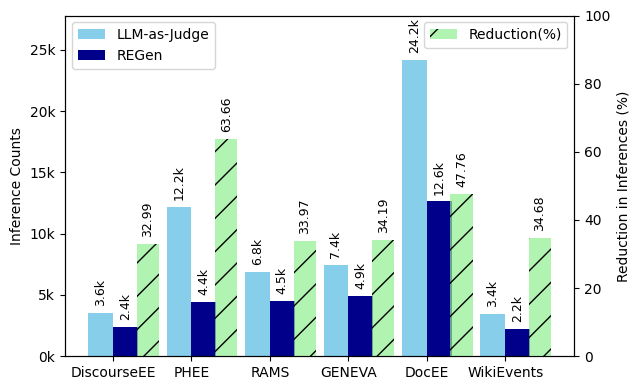

In [50]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# Data from the table
datasets, em_scores, mlm_scores, reductions = df['Dataset'], df['LLM-as-Judge'], df['REGen'], df['Reduction (%)']

# Create a bar chart
x = np.arange(len(datasets)) * 1.2 # Increase space between bars
width = 0.38  # the width of the bars

fig, ax = plt.subplots(figsize=(6.5, 4))

# Bar plots for LLM-as-Judge and REGen
bars1 = ax.bar(x - width/2, em_scores, width, color='skyblue', label='LLM-as-Judge')
bars2 = ax.bar(x + width/2, mlm_scores, width, color='darkblue',  label='REGen')

# Create a secondary axis for the reduction percentages
ax2 = ax.twinx()
bars3 = ax2.bar(x + width * 1.4, reductions, width * 0.9, color='lightgreen', hatch='/', label='Reduction(%)', alpha=0.7)

# Set labels and ticks
ax.set_ylabel('Inference Counts')
ax2.set_ylabel('Reduction in Inferences (%)')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylim(0, max(max(em_scores), max(mlm_scores)) * 1.15)
ax2.set_ylim(0, 100)

# Format y-axis labels to show in 'k'
def format_k(value, _):
    return f'{value/1000:.0f}k'

ax.yaxis.set_major_formatter(FuncFormatter(format_k))

# Add legends for both axes
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

# Add bar labels with formatted counts
def format_counts(value):
    return f'{value/1000:.1f}k'

ax.bar_label(bars1, padding=5, size=9, labels=[format_counts(v) for v in em_scores], rotation=90)
ax.bar_label(bars2, padding=5, size=9, labels=[format_counts(v) for v in mlm_scores], rotation=90)
ax2.bar_label(bars3, padding=5, size=9, rotation=90)

fig.tight_layout()

# Save the figure with DPI control
# filename = 'inference-count-and-reduction-comparison.png'
# fig.savefig(filename, dpi=1000, bbox_inches='tight')  # Save with higher DPI

plt.show()

## Baseline Results

In [51]:
def get_baseline_results(dataset_name, model_name, threshold, judge_model, version):
    print(f"--{dataset_name}----{model_name}--------")

    results_path = os.path.join(workspace_path, 'Result')
    file_name = f'{model_name}-QA-after-complex-match-predictions-{dataset_name}-v{version}.json'
    with open(os.path.join(results_path, dataset_name, file_name), 'r') as json_file:
          predictions = json.load(json_file)

    path = workspace_path
    judgment_deviation_scores = read_json_file(os.path.join(path, 'judgment-deviation-scores.json'))
    unique_roles = list({d['role'] for d in predictions if 'role' in d})

    #printing the results
    results = overall_score_on_whole_data(predictions, unique_roles, threshold, judge_model,
                                      dataset_name, judgment_deviation_scores)

    #overall precision, recall, and f1-score
    lst1 =['exact-match', 'relaxed-match', 'complex-match', 'jam']
    lst2 = ['precision', 'recall', 'f1']

    final_results = {
        'Model': model_name
    }
    for l1 in lst1:
      #print("\n******")
      for l2 in lst2:
          key = f'{l1}-{l2}'
          value = results[key]
          final_results[key] = value
    #print("******")

    return final_results

In [52]:
threshold = 0.85
judge_model = 'GPT-4o'
version = 1

dataset_names = ["DiscourseEE", 'PHEE', 'RAMS', 'GENEVA', 'DocEE', 'WikiEvents']
model_names = ['BERT', 'FLAN-T5']

all_baseline_results = {}
for dataset_name in dataset_names:
    for model_name in model_names:
        results = get_baseline_results(dataset_name, model_name, threshold, judge_model, version)
        pprint(results)
        all_baseline_results[f"{dataset_name}-{model_name}"] = results

print(all_baseline_results)


--DiscourseEE----BERT--------
873
GT: 997, PD: 873, EM:(55, 55), RM:(26, 26), CM: (239, 226), EM+RM+CM: 320
{'Model': 'BERT',
 'complex-match-f1': 33.56,
 'complex-match-precision': 35.17,
 'complex-match-recall': 32.1,
 'exact-match-f1': 5.88,
 'exact-match-precision': 6.3,
 'exact-match-recall': 5.52,
 'jam-f1': 30.18,
 'jam-precision': 31.65,
 'jam-recall': 28.84,
 'relaxed-match-f1': 8.66,
 'relaxed-match-precision': 9.28,
 'relaxed-match-recall': 8.12}
--DiscourseEE----FLAN-T5--------
873
GT: 997, PD: 873, EM:(63, 63), RM:(32, 32), CM: (256, 235), EM+RM+CM: 351
{'Model': 'FLAN-T5',
 'complex-match-f1': 36.46,
 'complex-match-precision': 37.8,
 'complex-match-recall': 35.21,
 'exact-match-f1': 6.74,
 'exact-match-precision': 7.22,
 'exact-match-recall': 6.32,
 'jam-f1': 32.87,
 'jam-precision': 34.13,
 'jam-recall': 31.71,
 'relaxed-match-f1': 10.16,
 'relaxed-match-precision': 10.88,
 'relaxed-match-recall': 9.53}
--PHEE----BERT--------
4528
GT: 4952, PD: 4528, EM:(1317, 1317), RM

In [53]:
all_results_df = pd.DataFrame(all_baseline_results).T
all_results_df

,Model,exact-match-precision,exact-match-recall,exact-match-f1,relaxed-match-precision,relaxed-match-recall,relaxed-match-f1,complex-match-precision,complex-match-recall,complex-match-f1,jam-precision,jam-recall,jam-f1
DiscourseEE-BERT,BERT,6.3,5.52,5.88,9.28,8.12,8.66,35.17,32.1,33.56,31.65,28.84,30.18
DiscourseEE-FLAN-T5,FLAN-T5,7.22,6.32,6.74,10.88,9.53,10.16,37.8,35.21,36.46,34.13,31.71,32.87
PHEE-BERT,BERT,29.09,26.6,27.78,36.62,33.48,34.98,54.88,50.53,52.61,53.55,49.28,51.33
PHEE-FLAN-T5,FLAN-T5,44.32,40.53,42.34,52.8,48.28,50.44,69.96,64.24,66.98,68.71,63.07,65.77
RAMS-BERT,BERT,14.63,14.63,14.63,18.14,18.14,18.14,33.61,33.61,33.61,32.24,32.24,32.24
RAMS-FLAN-T5,FLAN-T5,12.61,12.61,12.61,15.13,15.13,15.13,28.62,28.62,28.62,27.43,27.43,27.43
GENEVA-BERT,BERT,15.81,14.72,15.24,27.56,25.67,26.58,54.64,51.62,53.09,52.24,49.33,50.74
GENEVA-FLAN-T5,FLAN-T5,19.02,17.71,18.34,32.0,29.79,30.85,59.63,56.01,57.76,57.16,53.67,55.36
DocEE-BERT,BERT,22.93,15.73,18.66,31.59,21.72,25.74,57.09,41.12,47.81,52.73,37.82,44.05
DocEE-FLAN-T5,FLAN-T5,22.8,15.64,18.55,30.62,21.08,24.97,54.35,38.98,45.4,50.29,35.94,41.92


In [54]:
lst1 =['exact-match', 'relaxed-match', 'complex-match', 'jam']

for id, value in all_results_df.iterrows():
    print(id)
    for ls in lst1:
      print(value[f'{ls}-f1'])

DiscourseEE-BERT
5.88
8.66
33.56
30.18
DiscourseEE-FLAN-T5
6.74
10.16
36.46
32.87
PHEE-BERT
27.78
34.98
52.61
51.33
PHEE-FLAN-T5
42.34
50.44
66.98
65.77
RAMS-BERT
14.63
18.14
33.61
32.24
RAMS-FLAN-T5
12.61
15.13
28.62
27.43
GENEVA-BERT
15.24
26.58
53.09
50.74
GENEVA-FLAN-T5
18.34
30.85
57.76
55.36
DocEE-BERT
18.66
25.74
47.81
44.05
DocEE-FLAN-T5
18.55
24.97
45.4
41.92
WikiEvents-BERT
6.46
9.55
29.44
27.2
WikiEvents-FLAN-T5
9.27
11.8
29.4
27.41


## REGen Results

In [55]:
def get_results(dataset_name, model_name, threshold, judge_model, prompt_type, version):
    print(f"--{dataset_name}----{model_name}--------")
    print(prompt_type, "||", version)
    path = workspace_path

    predictions, event_schema = get_predictions_for_results(path, model_name, dataset_name, prompt_type, version)
    judgment_deviation_scores = read_json_file(os.path.join(path, 'judgment-deviation-scores.json'))
    unique_roles = list({d['role'] for d in predictions if 'role' in d})

    #printing the results
    results = overall_score_on_whole_data(predictions, unique_roles, threshold, judge_model,
                                      dataset_name, judgment_deviation_scores)

    #overall precision, recall, and f1-score
    lst1 =['exact-match', 'relaxed-match', 'complex-match', 'jam']
    lst2 = ['precision', 'recall', 'f1']

    final_results = {
        'Model': model_name
    }
    for l1 in lst1:
      #print("\n******")
      for l2 in lst2:
          key = f'{l1}-{l2}'
          value = results[key]
          #print(key, value)
          final_results[key] = value
    #print("******")

    return final_results

In [56]:
#@title All Results
dataset_names = ["DiscourseEE", 'PHEE', 'RAMS', 'GENEVA', 'DocEE', 'WikiEvents']
model_names = ['Phi-3.5', 'Gemma1.1-7B', 'Mixtral-8x7B', 'Llama3.1-70B', 'GPT-4o']
threshold = 0.85
judge_model = 'GPT-4o'

prompt_types = ['zero-shot', 'cot']
versions = [1]
all_results = {}

for dataset_name in dataset_names:
    for version in versions:
        for prompt_type in prompt_types:
            full_results = []
            for model_name in model_names:
                results = get_results(dataset_name, model_name, threshold, judge_model, prompt_type, version)
                full_results.append(results)
            df_results = pd.DataFrame(full_results)
            all_results[f"{dataset_name}-{prompt_type}-{version}"] = df_results

print(all_results.keys())

--DiscourseEE----Phi-3.5--------
zero-shot || 1
873
GT: 997, PD: 1121, EM:(36, 36), RM:(17, 17), CM: (93, 113), EM+RM+CM: 169
--DiscourseEE----Gemma1.1-7B--------
zero-shot || 1
873
GT: 997, PD: 1311, EM:(137, 137), RM:(46, 46), CM: (372, 415), EM+RM+CM: 616
--DiscourseEE----Mixtral-8x7B--------
zero-shot || 1
873
GT: 997, PD: 1614, EM:(171, 171), RM:(60, 61), CM: (347, 443), EM+RM+CM: 687
--DiscourseEE----Llama3.1-70B--------
zero-shot || 1
873
GT: 997, PD: 1530, EM:(169, 169), RM:(67, 68), CM: (282, 337), EM+RM+CM: 583
--DiscourseEE----GPT-4o--------
zero-shot || 1
873
GT: 997, PD: 1464, EM:(207, 207), RM:(77, 77), CM: (290, 360), EM+RM+CM: 649
--DiscourseEE----Phi-3.5--------
cot || 1
873
GT: 997, PD: 1772, EM:(98, 98), RM:(72, 75), CM: (352, 434), EM+RM+CM: 626
--DiscourseEE----Gemma1.1-7B--------
cot || 1
873
GT: 997, PD: 1592, EM:(121, 121), RM:(48, 48), CM: (342, 427), EM+RM+CM: 614
--DiscourseEE----Mixtral-8x7B--------
cot || 1
873
GT: 997, PD: 1088, EM:(52, 52), RM:(21, 21), C

In [57]:
#@title DiscourseEE
all_results['DiscourseEE-zero-shot-1']

,Model,exact-match-precision,exact-match-recall,exact-match-f1,relaxed-match-precision,relaxed-match-recall,relaxed-match-f1,complex-match-precision,complex-match-recall,complex-match-f1,jam-precision,jam-recall,jam-f1
0,Phi-3.5,3.21,3.61,3.40,4.73,5.32,5.00,14.81,14.64,14.73,13.43,13.36,13.39
1,Gemma1.1-7B,10.45,13.74,11.87,13.96,18.36,15.86,45.61,55.67,50.14,41.31,50.58,45.48
2,Mixtral-8x7B,10.59,17.15,13.10,14.37,23.17,17.74,41.82,57.97,48.59,38.07,53.19,44.38
3,Llama3.1-70B,11.05,16.95,13.38,15.49,23.67,18.73,37.52,51.96,43.57,34.47,48.02,40.13
4,GPT-4o,14.14,20.76,16.82,19.40,28.49,23.08,43.99,57.57,49.87,40.58,53.50,46.16


In [58]:
all_results['DiscourseEE-cot-1']

,Model,exact-match-precision,exact-match-recall,exact-match-f1,relaxed-match-precision,relaxed-match-recall,relaxed-match-f1,complex-match-precision,complex-match-recall,complex-match-f1,jam-precision,jam-recall,jam-f1
0,Phi-3.5,5.53,9.83,7.08,9.76,17.05,12.42,34.26,52.36,41.41,30.89,47.47,37.43
1,Gemma1.1-7B,7.60,12.14,9.35,10.62,16.95,13.06,37.44,51.25,43.27,33.79,46.57,39.16
2,Mixtral-8x7B,4.78,5.22,4.99,6.71,7.32,7.00,26.01,26.78,26.39,23.39,24.14,23.76
3,Llama3.1-70B,10.81,15.25,12.65,14.79,20.86,17.31,39.83,51.05,44.75,36.40,46.89,40.98
4,GPT-4o,12.64,17.75,14.77,17.86,25.08,20.86,42.71,53.06,47.33,39.27,49.15,43.66


In [59]:
#@title PHEE
all_results['PHEE-zero-shot-1']

,Model,exact-match-precision,exact-match-recall,exact-match-f1,relaxed-match-precision,relaxed-match-recall,relaxed-match-f1,complex-match-precision,complex-match-recall,complex-match-f1,jam-precision,jam-recall,jam-f1
0,Phi-3.5,39.07,47.88,43.03,45.84,56.12,50.46,62.61,73.63,67.67,61.39,72.35,66.42
1,Gemma1.1-7B,44.10,45.94,45.00,53.23,55.49,54.34,75.91,77.99,76.93,74.25,76.35,75.28
2,Mixtral-8x7B,33.68,40.02,36.58,39.16,46.59,42.55,55.39,63.55,59.19,54.20,62.31,57.98
3,Llama3.1-70B,36.49,42.29,39.17,43.77,50.63,46.95,61.53,66.60,63.96,60.23,65.43,62.72
4,GPT-4o,51.38,56.18,53.67,59.34,64.74,61.92,77.36,80.63,78.96,76.04,79.47,77.72


In [60]:
all_results['PHEE-cot-1']

,Model,exact-match-precision,exact-match-recall,exact-match-f1,relaxed-match-precision,relaxed-match-recall,relaxed-match-f1,complex-match-precision,complex-match-recall,complex-match-f1,jam-precision,jam-recall,jam-f1
0,Phi-3.5,30.57,33.76,32.09,36.24,39.96,38.01,52.68,55.45,54.03,51.48,54.32,52.86
1,Gemma1.1-7B,33.39,34.92,34.14,41.35,43.26,42.28,60.99,61.93,61.46,59.56,60.57,60.06
2,Mixtral-8x7B,29.12,29.81,29.46,36.87,37.70,37.28,50.90,50.61,50.75,49.87,49.66,49.77
3,Llama3.1-70B,30.44,32.19,31.29,38.87,41.05,39.93,52.20,52.83,52.51,51.22,51.97,51.59
4,GPT-4o,46.91,49.43,48.14,54.27,57.13,55.66,69.68,70.34,70.01,68.56,69.37,68.96


In [61]:
#@title RAMS
all_results['RAMS-zero-shot-1']

,Model,exact-match-precision,exact-match-recall,exact-match-f1,relaxed-match-precision,relaxed-match-recall,relaxed-match-f1,complex-match-precision,complex-match-recall,complex-match-f1,jam-precision,jam-recall,jam-f1
0,Phi-3.5,13.75,17.35,15.34,16.07,20.27,17.92,31.23,37.77,34.19,29.90,36.22,32.76
1,Gemma1.1-7B,14.40,15.37,14.87,16.95,18.09,17.50,31.45,33.47,32.43,30.17,32.11,31.11
2,Mixtral-8x7B,11.30,15.22,12.97,13.47,18.14,15.46,26.42,34.50,29.93,25.28,33.06,28.65
3,Llama3.1-70B,9.98,14.88,11.95,12.20,18.04,14.56,21.82,30.50,25.44,20.96,29.39,24.47
4,GPT-4o,15.01,27.58,19.44,17.89,32.82,23.15,29.91,49.98,37.42,28.84,48.43,36.15


In [62]:
all_results['RAMS-cot-1']

,Model,exact-match-precision,exact-match-recall,exact-match-f1,relaxed-match-precision,relaxed-match-recall,relaxed-match-f1,complex-match-precision,complex-match-recall,complex-match-f1,jam-precision,jam-recall,jam-f1
0,Phi-3.5,14.15,17.20,15.53,17.00,20.66,18.65,31.96,37.57,34.54,30.64,36.07,33.13
1,Gemma1.1-7B,10.17,11.32,10.71,12.88,14.34,13.57,25.13,27.53,26.28,24.04,26.36,25.15
2,Mixtral-8x7B,6.08,7.86,6.85,7.34,9.49,8.28,15.33,19.08,17.00,14.63,18.23,16.23
3,Llama3.1-70B,9.28,12.51,10.66,11.12,14.98,12.76,21.21,26.89,23.72,20.32,25.83,22.75
4,GPT-4o,12.77,19.72,15.50,16.13,24.91,19.58,28.55,40.68,33.56,27.44,39.26,32.30


In [63]:
#@title GENEVA
all_results['GENEVA-zero-shot-1']

,Model,exact-match-precision,exact-match-recall,exact-match-f1,relaxed-match-precision,relaxed-match-recall,relaxed-match-f1,complex-match-precision,complex-match-recall,complex-match-f1,jam-precision,jam-recall,jam-f1
0,Phi-3.5,12.21,14.36,13.20,23.56,27.68,25.46,47.65,52.14,49.80,45.50,49.92,47.61
1,Gemma1.1-7B,11.75,11.63,11.69,24.52,24.27,24.40,51.41,50.06,50.73,49.01,47.75,48.37
2,Mixtral-8x7B,12.20,14.65,13.31,22.80,27.32,24.86,45.98,51.17,48.44,43.92,49.01,46.32
3,Llama3.1-70B,15.04,17.93,16.36,27.24,32.46,29.62,52.74,57.67,55.09,50.45,55.36,52.79
4,GPT-4o,17.72,20.86,19.16,30.86,36.29,33.35,56.25,60.49,58.30,53.96,58.25,56.02


In [64]:
all_results['GENEVA-cot-1']

,Model,exact-match-precision,exact-match-recall,exact-match-f1,relaxed-match-precision,relaxed-match-recall,relaxed-match-f1,complex-match-precision,complex-match-recall,complex-match-f1,jam-precision,jam-recall,jam-f1
0,Phi-3.5,9.98,11.66,10.76,20.22,23.55,21.76,44.22,48.60,46.31,42.09,46.36,44.12
1,Gemma1.1-7B,9.21,9.55,9.38,20.83,21.60,21.21,45.69,45.32,45.51,43.47,43.18,43.33
2,Mixtral-8x7B,15.39,17.48,16.37,25.17,28.59,26.77,45.08,49.25,47.07,43.29,47.38,45.24
3,Llama3.1-70B,9.29,9.65,9.46,16.98,17.61,17.29,33.15,31.03,32.05,31.70,29.79,30.72
4,GPT-4o,16.00,17.12,16.54,27.57,29.50,28.50,48.50,48.47,48.48,46.59,46.71,46.65


In [65]:
#@title DocEE
all_results['DocEE-zero-shot-1']

,Model,exact-match-precision,exact-match-recall,exact-match-f1,relaxed-match-precision,relaxed-match-recall,relaxed-match-f1,complex-match-precision,complex-match-recall,complex-match-f1,jam-precision,jam-recall,jam-f1
0,Phi-3.5,14.16,14.36,14.26,19.86,20.04,19.95,39.18,37.62,38.39,35.90,34.62,35.25
1,Gemma1.1-7B,20.47,16.04,17.99,30.38,23.95,26.78,51.92,42.54,46.77,48.15,39.31,43.28
2,Mixtral-8x7B,21.84,24.09,22.91,31.06,34.20,32.55,56.50,59.92,58.16,52.12,55.47,53.74
3,Llama3.1-70B,15.03,21.11,17.56,21.65,29.97,25.14,42.51,51.17,46.44,38.95,47.49,42.80
4,GPT-4o,16.82,31.42,21.91,24.45,44.89,31.65,45.79,73.41,56.40,42.12,68.41,52.14


In [66]:
all_results['DocEE-cot-1']

,Model,exact-match-precision,exact-match-recall,exact-match-f1,relaxed-match-precision,relaxed-match-recall,relaxed-match-f1,complex-match-precision,complex-match-recall,complex-match-f1,jam-precision,jam-recall,jam-f1
0,Phi-3.5,18.95,20.82,19.84,26.57,29.13,27.79,46.94,50.19,48.51,43.43,46.55,44.93
1,Gemma1.1-7B,10.90,9.01,9.87,16.20,13.47,14.71,28.44,23.98,26.02,26.30,22.15,24.05
2,Mixtral-8x7B,7.84,6.17,6.90,10.93,8.60,9.63,22.38,16.94,19.28,20.44,15.53,17.65
3,Llama3.1-70B,16.81,24.07,19.79,25.26,35.97,29.68,48.02,61.66,53.99,44.10,57.15,49.78
4,GPT-4o,17.78,29.77,22.26,25.56,42.48,31.92,47.90,71.18,57.27,44.07,66.17,52.90


In [67]:
#@title WikiEvents
all_results['WikiEvents-zero-shot-1']

,Model,exact-match-precision,exact-match-recall,exact-match-f1,relaxed-match-precision,relaxed-match-recall,relaxed-match-f1,complex-match-precision,complex-match-recall,complex-match-f1,jam-precision,jam-recall,jam-f1
0,Phi-3.5,9.80,8.46,9.08,11.76,10.15,10.90,36.76,32.56,34.53,33.94,30.03,31.86
1,Gemma1.1-7B,8.65,4.86,6.22,10.15,5.71,7.31,40.98,29.60,34.37,37.49,26.90,31.32
2,Mixtral-8x7B,10.55,9.30,9.89,13.19,11.63,12.36,39.09,37.42,38.24,36.16,34.51,35.31
3,Llama3.1-70B,11.06,15.22,12.81,13.36,18.39,15.48,33.95,45.67,38.94,31.62,42.58,36.29
4,GPT-4o,11.47,17.34,13.80,14.13,21.35,17.00,35.10,51.80,41.85,32.73,48.36,39.04


In [68]:
all_results['WikiEvents-cot-1']

,Model,exact-match-precision,exact-match-recall,exact-match-f1,relaxed-match-precision,relaxed-match-recall,relaxed-match-f1,complex-match-precision,complex-match-recall,complex-match-f1,jam-precision,jam-recall,jam-f1
0,Phi-3.5,7.82,6.13,6.87,9.70,7.61,8.53,35.04,29.39,31.97,32.18,26.93,29.32
1,Gemma1.1-7B,4.53,2.54,3.25,6.42,3.59,4.61,22.26,14.59,17.63,20.47,13.35,16.16
2,Mixtral-8x7B,5.96,3.59,4.49,8.07,4.86,6.07,24.56,16.28,19.58,22.70,14.99,18.06
3,Llama3.1-70B,10.78,10.78,10.78,13.11,13.11,13.11,35.94,37.21,36.56,33.36,34.49,33.91
4,GPT-4o,10.77,13.95,12.15,13.38,17.34,15.10,37.36,47.78,41.93,34.65,44.34,38.90


## F1-scores

In [69]:
dataset_names = ["DiscourseEE", 'PHEE', 'RAMS', 'GENEVA', 'DocEE', 'WikiEvents']
prompt_types = ['zero-shot', 'cot']
lst1 =['exact-match', 'relaxed-match', 'complex-match', 'jam']

for prompt_type in prompt_types:
    for dataset_name in dataset_names:
        dt = {}
        for ls in lst1:
            df = all_results[f"{dataset_name}-{prompt_type}-1"][f'{ls}-f1']
            dt[ls] = df
        print(prompt_type, "||", dataset_name)
        print(pd.DataFrame(dt))

zero-shot || DiscourseEE
   exact-match  relaxed-match  complex-match    jam
0         3.40           5.00          14.73  13.39
1        11.87          15.86          50.14  45.48
2        13.10          17.74          48.59  44.38
3        13.38          18.73          43.57  40.13
4        16.82          23.08          49.87  46.16
zero-shot || PHEE
   exact-match  relaxed-match  complex-match    jam
0        43.03          50.46          67.67  66.42
1        45.00          54.34          76.93  75.28
2        36.58          42.55          59.19  57.98
3        39.17          46.95          63.96  62.72
4        53.67          61.92          78.96  77.72
zero-shot || RAMS
   exact-match  relaxed-match  complex-match    jam
0        15.34          17.92          34.19  32.76
1        14.87          17.50          32.43  31.11
2        12.97          15.46          29.93  28.65
3        11.95          14.56          25.44  24.47
4        19.44          23.15          37.42  36.15
zer

## Average improvment on each dataset

In [70]:
dataset_names = ["DiscourseEE", 'PHEE', 'RAMS', 'GENEVA', 'DocEE', 'WikiEvents']
model_names = ['Phi-3.5', 'Gemma1.1-7B', 'Mixtral-8x7B', 'Llama3.1-70B', 'GPT-4o']
threshold = 0.85
judge_model = 'GPT-4o'

prompt_types = ['zero-shot', 'cot']

full_results = {}

for dataset_name in dataset_names:
    model_wise_score = {}
    for model_name in model_names:
        prompt_wise_score = {}
        for prompt_type in prompt_types:
            results = get_results(dataset_name, model_name, threshold, judge_model, prompt_type, 1)
            prompt_wise_score[prompt_type] = results
        model_wise_score[model_name] = prompt_wise_score
    full_results[dataset_name]= copy.deepcopy(model_wise_score)

full_results

--DiscourseEE----Phi-3.5--------
zero-shot || 1
873
GT: 997, PD: 1121, EM:(36, 36), RM:(17, 17), CM: (93, 113), EM+RM+CM: 169
--DiscourseEE----Phi-3.5--------
cot || 1
873
GT: 997, PD: 1772, EM:(98, 98), RM:(72, 75), CM: (352, 434), EM+RM+CM: 626
--DiscourseEE----Gemma1.1-7B--------
zero-shot || 1
873
GT: 997, PD: 1311, EM:(137, 137), RM:(46, 46), CM: (372, 415), EM+RM+CM: 616
--DiscourseEE----Gemma1.1-7B--------
cot || 1
873
GT: 997, PD: 1592, EM:(121, 121), RM:(48, 48), CM: (342, 427), EM+RM+CM: 614
--DiscourseEE----Mixtral-8x7B--------
zero-shot || 1
873
GT: 997, PD: 1614, EM:(171, 171), RM:(60, 61), CM: (347, 443), EM+RM+CM: 687
--DiscourseEE----Mixtral-8x7B--------
cot || 1
873
GT: 997, PD: 1088, EM:(52, 52), RM:(21, 21), CM: (194, 210), EM+RM+CM: 289
--DiscourseEE----Llama3.1-70B--------
zero-shot || 1
873
GT: 997, PD: 1530, EM:(169, 169), RM:(67, 68), CM: (282, 337), EM+RM+CM: 583
--DiscourseEE----Llama3.1-70B--------
cot || 1
873
GT: 997, PD: 1406, EM:(152, 152), RM:(56, 56), C

{'DiscourseEE': {'Phi-3.5': {'zero-shot': {'Model': 'Phi-3.5',
    'exact-match-precision': 3.21,
    'exact-match-recall': 3.61,
    'exact-match-f1': 3.4,
    'relaxed-match-precision': 4.73,
    'relaxed-match-recall': 5.32,
    'relaxed-match-f1': 5.0,
    'complex-match-precision': 14.81,
    'complex-match-recall': 14.64,
    'complex-match-f1': 14.73,
    'jam-precision': 13.43,
    'jam-recall': 13.36,
    'jam-f1': 13.39},
   'cot': {'Model': 'Phi-3.5',
    'exact-match-precision': 5.53,
    'exact-match-recall': 9.83,
    'exact-match-f1': 7.08,
    'relaxed-match-precision': 9.76,
    'relaxed-match-recall': 17.05,
    'relaxed-match-f1': 12.42,
    'complex-match-precision': 34.26,
    'complex-match-recall': 52.36,
    'complex-match-f1': 41.41,
    'jam-precision': 30.89,
    'jam-recall': 47.47,
    'jam-f1': 37.43}},
  'Gemma1.1-7B': {'zero-shot': {'Model': 'Gemma1.1-7B',
    'exact-match-precision': 10.45,
    'exact-match-recall': 13.74,
    'exact-match-f1': 11.87,
 

In [71]:
result_list = []
prmpt_types = ['zero-shot', 'cot']

for dataset_name in dataset_names:
    avg_em, avg_rm, avg_cm, avg_mlm = 0, 0, 0, 0
    for model_name in model_names:
        for prompt_type in prompt_types:
            avg_em += full_results[dataset_name][model_name][prompt_type]['exact-match-f1']
            avg_rm += full_results[dataset_name][model_name][prompt_type]['relaxed-match-f1']
            avg_cm += full_results[dataset_name][model_name][prompt_type]['complex-match-f1']
            avg_mlm += full_results[dataset_name][model_name][prompt_type]['jam-f1']
    avg_em /= len(model_names)*2
    avg_rm /= len(model_names)*2
    avg_cm /= len(model_names)*2
    avg_mlm /= len(model_names)*2
    rst = {
        'Dataset': dataset_name,
        'Avg-EM': round(avg_em, 2),
        'Avg-RM': round(avg_rm,2),
        'Avg-CM': round(avg_cm,2),
        'Avg-MLM': round(avg_mlm,2),
        'Delta-F1': round(avg_mlm - avg_em,2),
        'Improvement': round(((avg_mlm - avg_em) / avg_em)*100, 2)
    }
    pprint(rst)
    result_list.append(rst)

df = pd.DataFrame(result_list)
df

{'Avg-CM': 41.01,
 'Avg-EM': 10.74,
 'Avg-MLM': 37.45,
 'Avg-RM': 15.11,
 'Dataset': 'DiscourseEE',
 'Delta-F1': 26.71,
 'Improvement': 248.69}
{'Avg-CM': 63.55,
 'Avg-EM': 39.26,
 'Avg-MLM': 62.34,
 'Avg-RM': 46.94,
 'Dataset': 'PHEE',
 'Delta-F1': 23.08,
 'Improvement': 58.79}
{'Avg-CM': 29.45,
 'Avg-EM': 13.38,
 'Avg-MLM': 28.27,
 'Avg-RM': 16.14,
 'Dataset': 'RAMS',
 'Delta-F1': 14.89,
 'Improvement': 111.25}
{'Avg-CM': 48.18,
 'Avg-EM': 13.62,
 'Avg-MLM': 46.12,
 'Avg-RM': 25.32,
 'Dataset': 'GENEVA',
 'Delta-F1': 32.49,
 'Improvement': 238.52}
{'Avg-CM': 45.12,
 'Avg-EM': 17.33,
 'Avg-MLM': 41.65,
 'Avg-RM': 24.98,
 'Dataset': 'DocEE',
 'Delta-F1': 24.32,
 'Improvement': 140.36}
{'Avg-CM': 33.56,
 'Avg-EM': 8.93,
 'Avg-MLM': 31.02,
 'Avg-RM': 11.05,
 'Dataset': 'WikiEvents',
 'Delta-F1': 22.08,
 'Improvement': 247.18}


,Dataset,Avg-EM,Avg-RM,Avg-CM,Avg-MLM,Delta-F1,Improvement
0,DiscourseEE,10.74,15.11,41.01,37.45,26.71,248.69
1,PHEE,39.26,46.94,63.55,62.34,23.08,58.79
2,RAMS,13.38,16.14,29.45,28.27,14.89,111.25
3,GENEVA,13.62,25.32,48.18,46.12,32.49,238.52
4,DocEE,17.33,24.98,45.12,41.65,24.32,140.36
5,WikiEvents,8.93,11.05,33.56,31.02,22.08,247.18


In [72]:
print(df['Delta-F1'].mean())

23.92833333333333


## Best performance on each dataset

In [73]:
best_resutls = {'DiscourseEE': {'Dataset': 'DiscourseEE', 'EM': 16.8, 'MLM': 46.1},
'PHEE': {'Dataset': 'PHEE', 'EM': 53.6, 'MLM': 77.7},
'RAMS': {'Dataset': 'RAMS', 'EM': 19.4, 'MLM': 36.1},
'GENEVA': {'Dataset': 'GENEVA', 'EM': 19.1, 'MLM': 56.0},
'DocEE': {'Dataset': 'DocEE', 'EM': 22.9, 'MLM': 53.7},
'WikiEvents': {'Dataset': 'WikiEvents', 'EM': 13.8, 'MLM': 39.0}}

result_list = []
for dataset_name in dataset_names:
    rst = best_resutls[dataset_name]
    result_list.append(rst)

df = pd.DataFrame(result_list)
df['REGen']=df['MLM']
print(sum((df['REGen']-df['EM'])/df['REGen'])/6)
df

0.5478308733661251


,Dataset,EM,MLM,REGen
0,DiscourseEE,16.8,46.1,46.1
1,PHEE,53.6,77.7,77.7
2,RAMS,19.4,36.1,36.1
3,GENEVA,19.1,56.0,56.0
4,DocEE,22.9,53.7,53.7
5,WikiEvents,13.8,39.0,39.0


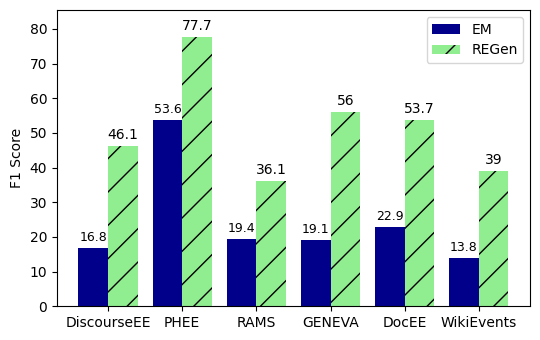

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
datasets, em_scores, mlm_scores = df['Dataset'], df['EM'], df['REGen']

# Create a bar chart
x = np.arange(len(datasets))  # the label locations
width = 0.40  # the width of the bars

fig, ax = plt.subplots(figsize=(5.5, 3.5))
bars1 = ax.bar(x - width/2, df['EM'], width, color = 'darkblue', label='EM')
bars2 = ax.bar(x + width/2, df['REGen'], width, label='REGen', color = 'lightgreen', hatch='/')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('F1 Score')
#ax.set_title('Performance comparison of EM and MLM evaluation framework', size=11)
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()

ax.set_ylim(0, max(max(em_scores), max(mlm_scores)) * 1.1)

# Add bar labels
ax.bar_label(bars1, padding=3, size=9)
ax.bar_label(bars2, padding=3, size =10)

fig.tight_layout()

# Save the figure with DPI control
# filename = 'performance-comparison.png'
# fig.savefig(filename, dpi=1000, bbox_inches='tight')  # Save with higher DPI

plt.show()